# 👋 Welcome to the introduction tutorial

In this tutorial, we will guide you, while using *puncc*, throughout the process of uncertainty quantification in a regression tasks. By the end of this notebook, you will be able to wrap your own models into conformal predictors and analyze their performance.

In addition, we will provide a guide on how to use conformal prediction for anomaly detection. Let's get started !

**Table of contents**

- [📈 Conformal Regression](#cr)
    - [💾 Diabetes Dataset](#cr-data)
    - [🔮 Predicton Model](#cr-pm)
    - [⚙️ Conformal Prediction](#cr-cp)

**Links**
- [<img src="https://github.githubassets.com/images/icons/emoji/octocat.png" width=20> Github](https://github.com/deel-ai/puncc)
- [📘 Documentation](https://deel-ai.github.io/puncc/index.html)

## 🛠️ Backend Configuration

**Puncc** supports various data types and model types.  
For this introductory notebook, we set the backend to NumPy.

In [1]:
from deel.puncc.config import set_backend

set_backend("torch")

## 📈 Conformal Regression  <a class="anchor" id="cr"></a>

Let’s consider a simple regression problem on diabetes data provided in Scikit-learn. We want to evaluate the uncertainty associated with the prediction using inductive (or split) conformal prediction.

### 💾 Diabetes Dataset <a class="anchor" id="cr-data"></a>

The dataset contains information about 442 diabetes patients. The goal is predict from physiological variables a quantitative measure of disease progression in one year.
- There are ten standardized features corresponding to the age, sex, body mass index, average blood pressure, and six blood serum measurements. 
- The target is the measure of diabetes progression during one year for each patient.

For more information, check the official [documentation](https://www4.stat.ncsu.edu/~boos/var.select/diabetes.html).

In [2]:
from sklearn import datasets
import torch
# Load the diabetes dataset
diabetes_X, diabetes_y = datasets.load_diabetes(return_X_y=True)

# Convert to torch
diabetes_X = torch.from_numpy(diabetes_X).float()
diabetes_y = torch.from_numpy(diabetes_y).float()

print(f"Features shape: {diabetes_X.shape}")
print(f"Target's shape: {diabetes_y.shape}")

Features shape: torch.Size([442, 10])
Target's shape: torch.Size([442])


From all the features, we want our model to capture only the link between body mass index and the evolution of the disease. 

In [3]:
import numpy as np 

# Use only BMI feature
diabetes_X = diabetes_X[:, 2].unsqueeze(1)
diabetes_y = diabetes_y.unsqueeze(1)

By construction, data are independent and identically distributed (i.i.d).

Great, we fullfill the prerequisites to apply conformal prediction 👏 !

The next step is spliting the data into three subsets:

* Fit subset ${\cal D_{fit}}$ to train the model.
* Calibration subset ${\cal D_{calib}}$ on which nonconformity scores are
  computed.
* Test subset ${\cal D_{test}}$ on which the prediction intervals are
  estimated.

---
**NOTE**

   Rigorously, for the probabilistic guarantee to hold, the calibration subset
   needs to be resampled for each new example in the test set.

---


The following code implements the aforementioned steps:

In [4]:
# Split the data into training/testing sets
X_train = diabetes_X[:-100]
X_test = diabetes_X[-100:]

# Split the targets into training/testing sets
y_train = diabetes_y[:-100]
y_test = diabetes_y[-100:]

# Split fit and calibration data
X_fit, X_calib = X_train[:-100], X_train[-100:]
y_fit, y_calib = y_train[:-100], y_train[-100:]

In [5]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)


torch.Size([342, 1]) torch.Size([100, 1]) torch.Size([342, 1]) torch.Size([100, 1])


### 🔮 Prediction Model <a class="anchor" id="cr-pm"></a>

We consider a simple linear regression model from
[scikit-learn regression module](https://scikit-learn.org/stable/modules/linear_model.html),
to be trained later on ${\cal D_{fit}}$:

In [6]:
from torch import nn


class LinearRegression(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.weight = nn.Parameter(torch.zeros(n_features, 1))
        self.bias = nn.Parameter(torch.zeros(1))

    def forward(self, X):
        return X @ self.weight + self.bias
    
    @torch.no_grad()
    def fit(self, X, y):
        if y.dim() == 1:
            y = y.unsqueeze(1)
        
        ones = torch.ones(X.size(0), 1, device=X.device, dtype=X.dtype)
        X_aug = torch.cat([ones, X], dim=1)

        solution = torch.linalg.lstsq(X_aug, y)
        beta = solution.solution

        self.bias.copy_(beta[0])
        self.weight.copy_(beta[1:])
        return self
    
# Create linear regression model
lin_reg_predictor = LinearRegression(n_features=1)


### ⚙️ Conformal Prediction <a class="anchor" id="cr-cp"></a>

For this example, the prediction intervals are obtained throught the split
conformal prediction method provided by the class
`deel.puncc.regression.SplitCP`. Other methods are presented
in the [documentation](https://deel-ai.github.io/puncc/regression.html).

In [7]:
from deel.puncc.regression import SplitCP

# Coverage target is 1-alpha = 90%
alpha=.1

# Instanciate the split cp wrapper around the linear predictor.
split_cp = SplitCP(lin_reg_predictor)

# Train model (if argument `is_train` is False) on the fitting dataset and
# compute the residuals on the calibration dataset. 
split_cp.fit(X_fit, y_fit)
split_cp.calibrate(X_calib, y_calib)

## Alternatively, we can randomly select the fit/calib subsets as below 
# split_cp.fit(X=X_train, y=y_train, fit_ratio=.8)

# The `predict` returns the output of the linear model `y_pred` and
# the calibrated interval [`y_pred_lower`, `y_pred_upper`].
y_pred, y_set= split_cp.predict(X_test, alpha=alpha)
y_pred_lower, y_pred_upper = y_set[..., 0], y_set[..., 1]

The library provides several metrics in `deel.puncc.metrics` to evaluate the conformalization procedure. Below, we compute the average empirical coverage and the average empirical width of the prediction intervals on the test examples:

In [8]:
from deel.puncc import metrics

coverage = metrics.regression_mean_coverage(y_test, y_pred_lower, y_pred_upper)
width = metrics.regression_sharpness(y_pred_lower=y_pred_lower,
                                    y_pred_upper=y_pred_upper)
print(f"Marginal coverage: {coverage:.2f}")
print(f"Average width: {width:.2f}")

Marginal coverage: 0.95
Average width: 211.38


In addition, puncc provides plotting tools in `deel.puncc.plotting` to visualize the prediction intervals and whether or not the observations are covered:

torch.Size([100, 1]) torch.Size([100, 1]) torch.Size([100, 1]) torch.Size([100, 1]) torch.Size([100, 1])


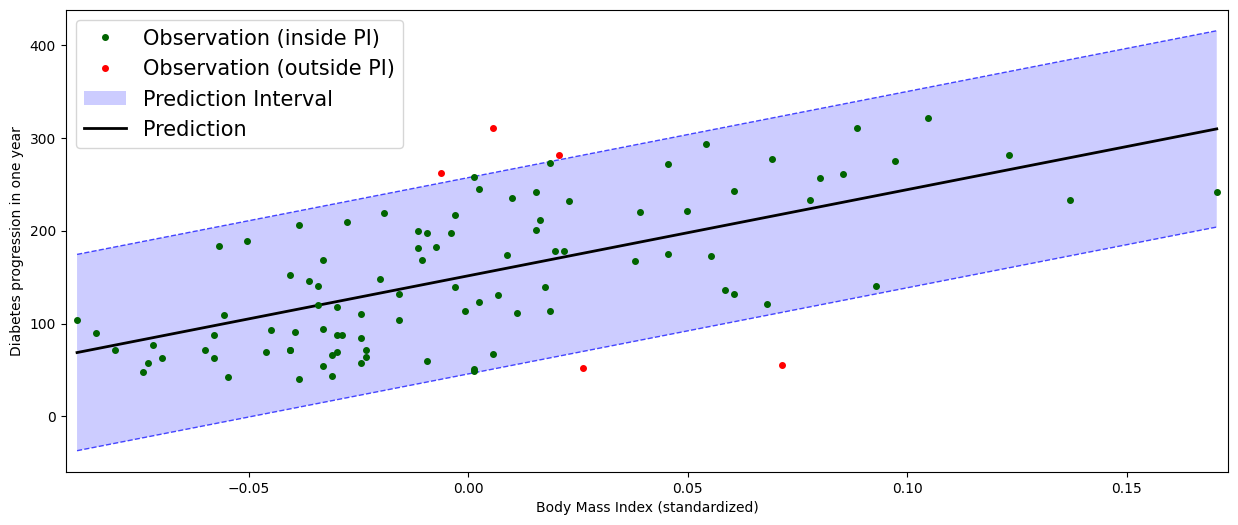

In [9]:
from deel.puncc.plotting import plot_prediction_intervals

# Figure of the prediction bands

print(X_test.shape, y_test.shape, y_pred.shape, y_pred_lower.shape, y_pred_upper.shape)

ax = plot_prediction_intervals(
        X = X_test.numpy().squeeze(),
        y_true=y_test.numpy().squeeze(),
        y_pred=y_pred.detach().numpy().squeeze(),
        y_pred_lower=y_pred_lower.detach().numpy().squeeze(),
        y_pred_upper=y_pred_upper.detach().numpy().squeeze(),
        loc="upper left")

_ = ax.set_xlabel("Body Mass Index (standardized)")
_ = ax.set_ylabel("Diabetes progression in one year")